<a href="https://colab.research.google.com/github/oviccenzo/inteligencia-artificial/blob/main/dataset_de_anomalia_da_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
#1 carregar dataset do titanic
df = pd.read_csv("transacoes_anomalias.csv")

In [ ]:
#1 linha do dataset do titanci
print("\nPrimeira linha do dataset: ")
print(df.head())


Primeira linha do dataset: 
    valor  frequencia  tempo_entre_compras    categoria
0  169.87          13                  9.1    vestuario
1  144.47          18                  8.1  eletronicos
2  175.91           9                  9.7  alimentacao
3  210.92           5                 12.1  eletronicos
4  140.63           7                  6.4  alimentacao


In [ ]:
print(df.head())

    valor  frequencia  tempo_entre_compras    categoria
0  169.87          13                  9.1    vestuario
1  144.47          18                  8.1  eletronicos
2  175.91           9                  9.7  alimentacao
3  210.92           5                 12.1  eletronicos
4  140.63           7                  6.4  alimentacao


In [ ]:
#Esse é a informação do dataset de titanic
print("\nInformações do dataset: ")
print(df.info())


Informações do dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valor                100 non-null    float64
 1   frequencia           100 non-null    int64  
 2   tempo_entre_compras  100 non-null    float64
 3   categoria            100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB
None


In [ ]:
# 2 Pré processamento
#Converter variáveis categóricas para numéricas
le_dict = {}

for col in df.select_dtypes(include='object').columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

In [ ]:
X = df.drop("valor", axis=1)
y = df["valor"]

In [ ]:
print("\nFeatures utilizados: ")
print(X.columns)


Features utilizados: 
Index(['frequencia', 'tempo_entre_compras', 'categoria'], dtype='object')


In [ ]:
#3 divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("\nAvaliação do modelo: ")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")


Avaliação do modelo: 
Mean Squared Error: 1836.58
R-squared: 0.94


In [ ]:
#Feature importance
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature" : X.columns,
    "importances" : importances
})


In [ ]:
feature_importances = feature_importance.sort_values(
    by="importances",
    ascending=False
)

In [ ]:
print(f"Feature importances")
print(feature_importances)

Feature importances
               feature  importances
0           frequencia     0.643647
1  tempo_entre_compras     0.348792
2            categoria     0.007561


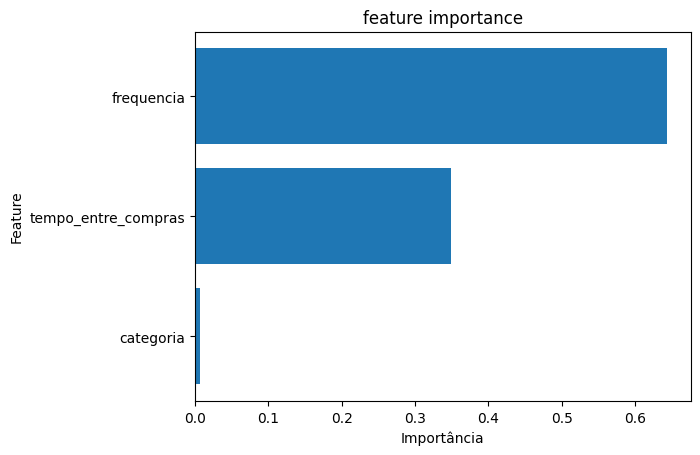

In [ ]:
plt.figure()
plt.barh(feature_importances["feature"], feature_importances["importances"])
plt.gca().invert_yaxis()
plt.title("feature importance")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

In [ ]:
#Sha
# Criar
Explainer = shap.TreeExplainer(model, X_train)

#Calcular os valores do shap
shap_value = Explainer.shap_values(X_test, check_additivity=False)

# Para modelos de regressão, shap_value já é 2D e não requer seleção de classe.
# A linha original 'shap_class = shap_value[:, :, 1]' causava um IndexError.
shap_class = shap_value

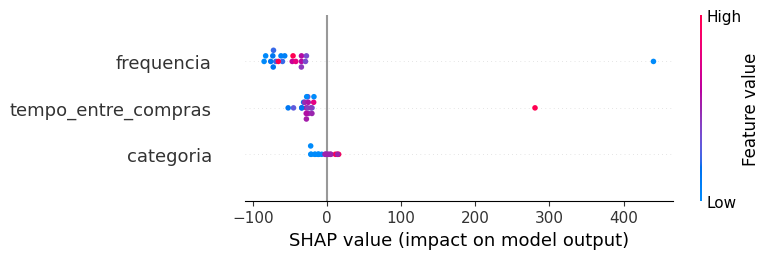

In [ ]:
shap.summary_plot(
    shap_class,
    X_test,
    feature_names = X_test.columns
)